# Approximation von Funktionen durch Taylorpolynome 
---

<b>Ausgabedatum:</b> 02.11.2022 <br>
<b>Abgabedatum:</b>  09.11.2022 <br>
Für Rückfragen zum Übungsbetrieb wenden Sie sich an: mustermann@w-hs.de<br><br>
<p>Haben Sie sich schon einmal gefragt, wie Ihr Taschenrechner eigentlich $\sin(3) $ ausrechnet? 

Computer sind darauf ausgelegt, addieren und multiplizieren zu können. Das bedeutet, dass sie gut Werte von Polynomen berechnen können. Werte anderer Funktionen können sie jedoch in der Regel nicht exakt berechnen. Daher verwenden viele Taschenrechner (und die Programmiersprachen) die Werte eines geeigneten Polynoms, um die Werte nichtlinearer Funktionen näherungsweise zu berechnen.

In der Vorlesung haben Sie Taylorpolynome kennen gelernt. Diese werden wir in diesem Notebook in diesem Kontext betrachten.

<b> Python Grundlagen: </b> einfache Schleifen, Plots, Verwendung der Bibliothek SymPy. <br>
<b> Mathematische Grundlagen:</b>  Fakultäten, Summenformeln, Hauptfunktionsarten (Polynomfunktionen, trigonometrische Funktionen, Exponentialfunktion, Logarithmusfunktion etc.), höhere Ableitungen<br>

<b>Inhaltsverzeichnis:</b> <br>
<ul>
 <li><a href="#errinerung">Erinnerung: Taylorpolynome</a></li>
 <li><a href="#einfuehrung">Einführendes Beispiel: Kleinwinkelnäherung</a></li>
 <li><a href="#graphic">Graphik: Approximationseigenschaft der Taylorpolynome</a></li>
 <li><a href="#parabel">Aufgabe: Taylorpolynom zweiter Ordnung ("Schmiegparabel")</a></li>
 <li><a href="#taylorsympy">Implementierung einer allgemeinen Routine zur Berechnung von Taylorpolynomen mit SymPy</a></li>
 <li><a href="#restglied">Fehlerabschätzung mit Hilfe der Restglieddarstellung von Lagrange</a></li>
 <li><a href="#vergleich">Zeitaufwandsvergleich der e-Funktion von Numpy und der selbst implementierten Approximation </a></li> 
</ul>
</p> 

In [1]:
# Import der benötigten Module
import numpy as np
import matplotlib.pyplot as plt
import math
import sympy as sp
import micropip
await micropip.install("ipywidgets")
from ipywidgets import interactive, widgets, interact, IntSlider
%matplotlib inline

<a id="errinerung"></a>
# Erinnerung: Taylorpolynome
---

In Ihrer Vorlesung haben Sie Taylorpolynome kennen gelernt: Für eine $n$-mal stetig differenzierbare Funktion $ f:f:\mathbb{R}\to\mathbb{R}$ ist ihr Taylorpolynom $ T^n_af: \mathbb{R}\to \mathbb{R}$ vom Grad $n\in\mathbb{N}$ zum Entwicklungspunkt $ a \in \mathbb{R}$ darüber definiert, dass es das (dadurch eindeutig definierte) Polynom $n$-ten Grades ist, dessen erste $ n $ Ableitungen an der Stelle $a$ mit denen von $f$ übereinstimmen. Das bedeutet:

- $ f(a) = T^n_a f(a) $
- $ f'(a) = T^n_af'(a) $
-  $ \vdots $
- $f^{(n)}(a) = T^n_af^{(n)}(a)$.

Aus diesen $n+1$ Bedingungen ergibt sich ein Gleichungssystem für die $n+1$ Koeffizienten von $T^n_af$, das eine eindeutige Lösung hat. Durch Lösen des Gleichungssystems ergibt sich die folgende Formel für das Taylorpolynom:

$$
\begin{align*}
T^n_a(x) &= f(a) + f'(a) (x-a) + \frac{1}{2} f''(a) \cdot(x-a)^2 + \cdots + \frac{1}{n!}f^{(n)}(a) \cdot (x-a)^n \\
&= \sum_{k=0}^n \frac{f^{(k)}(a)}{k!} \cdot (x-a)^k
\end{align*}
$$


<a id='einfuehrung'></a>

# Einführendes Beispiel: Kleinwinkelnäherung
---


Vielleicht haben Sie im Physik-Schulunterricht die sogenannte „Kleinwinkelnäherung“ kennengelernt: Für Winkel $\theta$ nahe $0$ macht man keinen großen Fehler, wenn man $\sin(\theta) \approx \theta$ rechnet (und vereinfacht dadurch viele Rechnungen erheblich, ohne einen großen Fehler in Kauf zu nehmen).
Wenn Sie den untenstehenden Code ausführen, sehen Sie, warum das so ist:
In beiden Plots sehen Sie die Funktionen $f(x)=\sin(x)$ und $g(x)=x$, rechts in einem größeren Maßstab als links, also quasi gezoomt auf $x=0$. 
Wie Sie wissen, ist 
$$f‘(0)=\cos(0)=1$$ 
und daher 
$$g(x)=x=f(0)+f‘(0)x$$ 
die Tangentenfunktion von $f$ an der Stelle $0$.
Diese ist darüber definiert, dass sie die (dadurch eindeutig bestimmte) lineare Funktion ist, deren Funktionswert und Ableitung an der Stelle $0$ mit denen von $f$ übereinstimmt. Ihre Funktionswerte sind „in der Nähe" von $0$ „ähnlich“ zu denen von $f$ – so ähnlich, dass man in einfachen Physik-Übungsaufgaben näherungsweise damit rechnen kann.



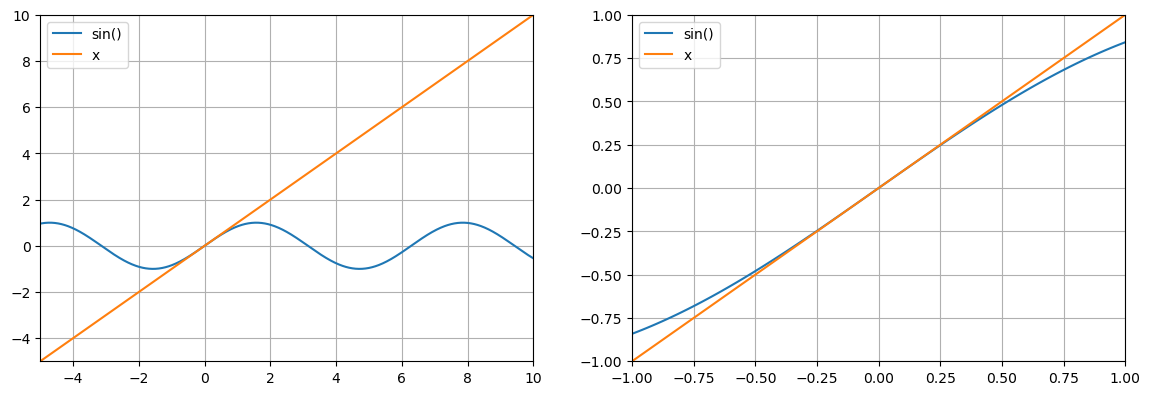

In [2]:
plt.figure(figsize = (14, 4.5)) # Diagrammgrösse festlegen
x = np.linspace(-10,10,1000)    # Liste an Werte erstellen im Bereich -10 bis 10  
y = np.sin(x)                   # Liste erstellen mit den Funktionwerte von sinus an den Stellen der Liste x
plt.subplot(1, 2, 1)            #
plt.xlim(-5, 10)                # Intervall der x-Achse im Diagramm festlegen
plt.ylim(-5, 10)                # Intervall der y-Achse im Diagramm festlegen
plt.plot(x,y,label="sin()")     # sin plotten    
plt.plot(x,x,label="x")         # x plotten
plt.legend()                    # Legende einschalten
plt.grid()                      # rechteckige Raster einschalten

x = np.linspace(-1,1,100)
y = np.sin(x)
plt.subplot(1, 2, 2)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.plot(x,y,label="sin()")
plt.plot(x,x,label="x")
plt.grid()
plt.legend()

<a id='graphik'></a>

# Graphik: Approximationseigenschaft der Taylorpolynome
---


In Ihrer Vorlesung haben Sie Taylorpolynome kennen gelernt: Diese sind gewissermaßen eine Verallgemeinerung von Tangenten: 
Das Taylorpolynom $n$-ter Ordnung von $f:\mathbb{R}\to \mathbb{R}$ im Entwicklungspunkt $a\in \mathbb{R}$ (kurz: $T^n_af$) ist darüber definiert, dass 
$$T^n_af^{(k)}(a) = f^{(k)}(a) \hbox{ für alle } k\in \{1,\ldots,n\}$$
gilt.
Das heißt mit anderen Worten: darüber, dass es in $a$ sowohl denselben Funktionswert als auch dieselben $n$ ersten Ableitungen hat wie $f$.

Dies sind lokale Eigenschaften, die erstmal nur im Punkt $a$ gelten. A priori ist nicht klar, dass das Taylorpolynom außerhalb von $a$ gute Näherungswerte für Funktionswerte von $f$ liefert.

Betrachtet man die Taylorpolynome zu einer gegebenen Funktion, so liefern diese jedoch in den meisten Fällen auf einer Umgebung von $a$ eine gute Näherung von $f$ -- und je höher der Polynomgrad $n$ wird, desto besser wird die Näherung.

Beschreiben Sie, was Sie in der untenstehenden Graphik in Bezug auf die Approximationseigenschaft der Taylorpolynome im Entwicklungspunkt $0$ der Sinus-Funktion sehen. Was hat das mit der oben beschriebenen "Kleinwinkelnäherung" zu tun?

In [3]:
def plot_func(Anzahl_Terme):
    x_werte = np.linspace(-5, 5, 1000)
    taylor_polynom = np.zeros(len(x_werte))

    for n in range(Anzahl_Terme):
        term = (-1)**n * x_werte**(2*n + 1) / np.math.factorial(2*n + 1)
        taylor_polynom += term

    max_poly_grad = 2 * Anzahl_Terme - 1
    plt.xlim(-5, 5)
    plt.ylim(-1.5, 1.5)
    plt.plot(x_werte, taylor_polynom, label=f"Taylorpolynom {max_poly_grad}. Grades")
    plt.plot(x_werte, np.sin(x_werte), label="$\sin(x)$")
    plt.legend()
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.show()

interact(plot_func, Anzahl_Terme=IntSlider(min=1, max=5, step=1, value=1))

interactive(children=(IntSlider(value=1, description='Anzahl_Terme', max=5, min=1), Output()), _dom_classes=('…

<function __main__.plot_func(Anzahl_Terme)>

<a id="parabel"></a>

# Aufgabe: Taylorpolynom zweiter Ordnung ("Schmiegparabel") für die Exponentialfunktion
---



Jetzt sind Sie an der Reihe!

Das Taylorpolynom zweiter Ordnung folgt bekanntermaßen der Abbildungsvorschrift

$T^2_a f(x) = f(a)+f'(a)(x-a)+\frac{1}{2} f''(a)(x-a)^2$

Da im Punkt $a$ sowohl der Funktionswert und die Steigung als auch die Krümmung mit der von $f$ übereinstimmt, "schmiegt" sich der Graph von $T^2_af(x)$ in $a$ an den Graphen von $f$ an. Daher bezeichnet man ihn auch als Schmiegparabel.

Ihr Auftrag besteht nun darin, zu überprüfen, ob diese auch für die Exponentialfunktion auf einem Intervall um $a$ eine gute Näherung für $f$ liefert. Dafür müssen Sie das obenstehende Codebeispiel (für $\sin(x)$) entsprechend anpassen und erweitern.

<div style= "color: black;background-color: powderblue ;margin: 10 px auto; padding: 10px; border-radius: 10px">
    <p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="4"><b>Aufgabe 1</b>  </p>

In dieser Aufgabe sollen Sie die Funktionen `f`, `df` und `ddf` vervollständigen, die jeweils die ursprüngliche Funktion $ f(x) $, ihre erste Ableitung $ f'(x) $ und ihre zweite Ableitung $ f''(x) $ repräsentieren. Außerdem sollen Sie die Ausdrücke für `tangent_line` und `parabula_line` formulieren, die die Tangente bzw. Parabel an der Funktion $ f(x) $ am Punkt $ a $ darstellen. 

Daraus werden zwei Plots erstellt: im linken werden die Funktion, ihre Tangente und ihre Schmiegparabel im Punkt $a$ geplottet. Im rechten wird der jeweilige Abstand zwischen den Funktionsgraphen aufgetragen, also der Fehler, den man macht, wenn man die Funktion durch ihr Taylorpolynom erster bzw zweiter Ordnung ersetzt.

Interpretieren Sie die Graphiken.

Wählen Sie hierbei $ f(x) = e^x$ und $a=0$, legen Sie Ihren Code aber so an, dass er möglichst einfach auf andere Funktionen und Entwicklungspunkte angepasst werden kann. 

**Zusätzlich zu vervollständigende Funktionen:**

- `tangent_line(x)`: Tangentengleichung an der Stelle $ a $.
- `parabula_line(x)`: Parabelgleichung, basierend auf der Taylor-Approximation 2. Ordnung an der Stelle $ a $.


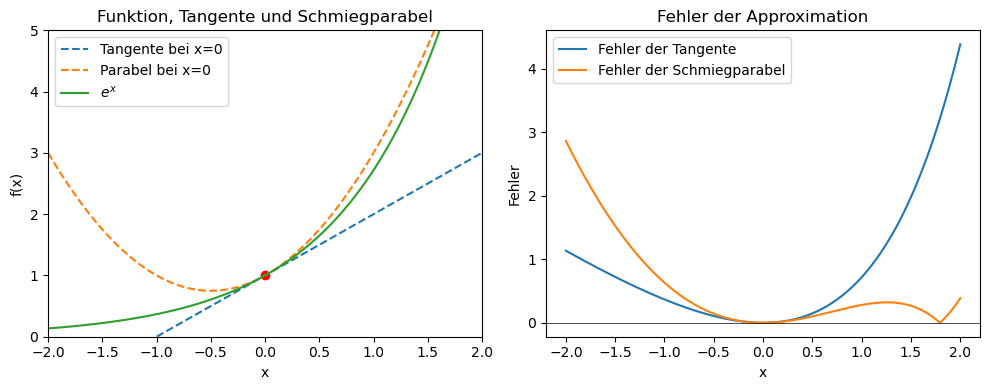

In [4]:
# Definition der Funktion und ihrer Ableitung
def f(x):
    return np.exp(x)

def df(x):
    return np.exp(x)

def ddf(x):
    return np.exp(x)

# Punkt a, an dem die Tangente gezeichnet wird
a = 0

# Koeffizienten der Tangentengleichung an diesem Punkt
def tangent_line(x): 
    return f(a) + df(a) * (x - a) 

# Koeffizienten der Schmiegparabel an diesem Punkt
def parabula_line(x):
    return f(a) + df(a) * (x - a) + ddf(a) * (x - a)**2

# Fehlerfunktion für die Tangente
def error_function(x):
    return f(x) - tangent_line(x)

# Fehlerfunktion für die Schmiegparabel
def error_function2(x):
    return f(x) - parabula_line(x)

# Werte für x 
x_values = np.linspace(-2, 2, 400)

# Plotten der Funktion, der Tangente, der Parabel  und des Fehlers
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.xlim(-2, 2)
plt.ylim(0, 5)

plt.plot(x_values, tangent_line(x_values), label='Tangente bei x=0', linestyle='--')
plt.plot(x_values, parabula_line(x_values), label='Parabel bei x=0', linestyle='--')
plt.plot(x_values, f(x_values), label='$e^x$')
plt.scatter(a, f(a), color='red') 
plt.title('Funktion, Tangente und Schmiegparabel')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Plotten des Fehlers der Approximation
plt.subplot(1, 2, 2)
plt.plot(x_values, abs(error_function(x_values)), label='Fehler der Tangente')
plt.title('Fehler der Approximation')
plt.plot(x_values, abs(error_function2(x_values)), label='Fehler der Schmiegparabel')
plt.xlabel('x')
plt.ylabel('Fehler')
plt.axhline(0, color='black', linewidth=0.5)
plt.legend()

plt.tight_layout()
plt.show()


<a id='taylorsympy'></a>

# Eigene Implementierung einer allgemeinen Routine zur Berechnung von Taylorpolynomen mit SymPy
---


Python ist nicht nur in der Lage, numerische Berechnungen durchzuführen, sondern unter der Verwendung der Bibliothek SymPy auch dazu, "symbolisch" zu rechnen: Das heißt, dass Python mit dieser Bibliothek wie ein Computeralgebrasystem verwendet werden kann. Insbesondere kann so eine Funktion als Variable übergeben werden, die automatisch differenziert wird. Das können wir insbesondere dafür nutzen, selbst eine allgemeine Routine zur Berechnung von Taylorpolynomen zu implementieren:

<div style= "color: black;background-color: powderblue ;margin: 10 px auto; padding: 10px; border-radius: 10px">
    <p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="3"><b>Aufgabe 2</b>  </p>

Implementieren Sie die Funktion `taylor_approximation(func, a, n, x_value)`. Die Parameter der Funktion repräsentieren die Variablen aus der Formel für das Taylorpolynom. Die Funktion soll den approximierten Wert der übergebenen Funktion berechnen. Verwenden Sie hierfür die Bibliothek Sympy, aber implementieren Sie die Formel des Taylor-Polynoms manuell, ohne vorimplementierte Funktionen von Sympy zu nutzen.

**Parameter:**

- `func`: Eine mathematische Funktion, definiert mit Sympy.
- `a`: Der Entwicklungspunkt des Taylor-Polynoms.
- `n`: Die Ordnung des Taylor-Polynoms.
- `x_value`: Der Wert, für den das Taylor-Polynom berechnet werden soll.

**Beispiel:**

Gegeben sei die Funktion $ f(x) = 3x^4 + 5x^2 - 7x $. Implementieren Sie `taylor_approximation` und berechnen Sie das Taylor-Polynom 3. Ordnung um den Punkt $ a = 1 $ für $ x = 2 $. FÜr diesen Aufruf solten ein Wert von 51 wiedergegeben werden. Zur weiteren Überprüfung steht ihnen die Methode `taylor_approximation_sympy(func, a, n, x_value)` zur Verfügung. Schauen Sie sich hierbei auch direkt an wie diese Methode funktioniert. 

**Hinweise zur Implementierung:**

- Sie können die Ableitungen der Funktion `func` in Sympy mit `sp.diff(func, x, i)` berechnen, wobei `i` die Ordnung der Ableitung ist.
- Verwenden Sie `subs` zum Einsetzen von Werten in Funktionen, z.B. `f1.subs(x, a)`.


</div>

In [5]:

"""
Deklaration einer Funktion in Sympy
x = sp.symbols('x')
f1 = 3*x**2 + 5*x - 7

Ermittlung eines Funktionswerts 
f1.subs(x,a)

Berechnung der Ableitung einer Funktion
i ist hierbei die i'te Ableitung
sp.diff(f1,x,i)
"""

# Hier sehen Sie die in SymPy vorimplementierte Routine zur Berechnung von Taylorpolynomen. Mit dieser Methode können Sie ihre Ergebnise vergleichen 
def taylor_approximation_sympy(funktion, a, n, x_wert):
    # taylorreihe aufstellen
    taylor_series = sp.series(funktion, x, a, n+1).removeO()
    # Funktionswert für x_wert berechnen
    taylor_value = taylor_series.subs(x, x_wert)
    return taylor_value

def taylor_approximation(funktion, a, n, x_wert):
    
    taylor_approximation = 0
    # Über die benötigte Ordnung iterieren
    for i in range(n+1):
        # nte Ableitung aufstellen
        nte_ableitung = sp.diff(funktion,x,i)
        # Funktionswert für a berechnen
        nte_ableitung_a = nte_ableitung.subs(x,a)
        # in Formel des Taylorpolynoms einsetzen
        taylor_approximation += (nte_ableitung_a / np.math.factorial(i)) * (x_wert - a)**i
    
    return taylor_approximation

x = sp.symbols('x')
f1 = 3*x**4 + 5*x**2 - 7*x

a = 1
n = 3
x_wert = 2

taylor_func = taylor_approximation(f1, a, n, x_wert)
taylor_func_sympy = taylor_approximation_sympy(f1, a, n, x_wert)

print(f"Funktionswert an der Stelle {x_wert}: {f1.subs(x,x_wert)}")
print(f"Wert des Taylorpolynoms (selbst implementiert) an der Stelle {x_wert}: {taylor_func}")
print(f"Wert des Taylorpolynoms (Sympy) an der Stelle {x_wert}: {taylor_func_sympy}")



Funktionswert an der Stelle 2: 54
Wert des Taylorpolynoms (selbst implementiert) an der Stelle 2: 51
Wert des Taylorpolynoms (Sympy) an der Stelle 2: 51


<a id="restglied"></a>

# Fehlerabschätzung mit Hilfe der Restglieddarstellung von Lagrange
---

Approximiert man eine nicht-polynomiale Funktion auf einem kompakten Intervall durch ein Taylorpolynom, so macht man dabei, wie bereits beobachtet, immer einen Approximationsfehler. Am Beispiel der Exponentialfunktion machen wir uns dies noch einmal deutlich, indem wir beobachten, wie groß dieser Fehler auf einem vorgegebenen Intervall ist:

In [7]:
# Diesen Code müssen Sie nicht nachvollziehen können
#-------------------------------------------
def plot_func(Ordnung, Intervallgrenze_links):
    a = np.arange(-2.5,2.5,0.1).round(2)
    np.put(a, [int(len(np.arange(-2.5,2.5,0.1))/2)],[0])
    opt = a[:int(len(np.arange(-2.5,2.5,0.1))/2) + 1]
    index = np.where(opt == Intervallgrenze_links)[0]

    x_werte = np.arange(-2.5,2.5,0.1).round(2) # Wertebereich von 2.5 bis - 2.5 erstellen

    taylor_polynom = np.zeros(len(x_werte))

    for n in range(Ordnung + 1):
        term = x_werte**n / math.factorial(n)
        taylor_polynom += term
    
    left = index[0] 
    right = (len(x_werte) - index[0])
    error = 0 if len(x_werte[left:right]) == 0 else max(abs(taylor_polynom[left:right] - np.exp(x_werte[left:right])))
    print(f"Der Fehler auf dem Intervall [{Intervallgrenze_links},{-Intervallgrenze_links}] beträgt maximal: {error}")
    plt.plot(x_werte,taylor_polynom, label=f"Taylorpolynom {Ordnung}.Ordnung") # Approximation plotten
    plt.plot(x_werte, np.exp(x_werte), label="$e^x$") # e-Funktion plotten
    if error == 0:
        plt.axvline(0,color="red")
    else:
        plt.axvline(x_werte[index + 1],color="red")
        plt.axvline(x_werte[(len(x_werte) - index) - 1],color="red")
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend() # Legende einschalten 
    plt.show() 
a = np.arange(-2.5,2.5,0.1).round(2)
np.put(a, [int(len(np.arange(-2.5,2.5,0.1))/2)],[0])
selection_slider = widgets.SelectionSlider(
    options= a[:int(len(np.arange(-2.5,2.5,0.1))/2) + 1],
    orientation='horizontal'
)
interactive(plot_func, Ordnung=widgets.IntSlider(min=1,max=4,step=1,value=1),Intervallgrenze_links=selection_slider) # interaktiven Plot anzeigen

interactive(children=(IntSlider(value=1, description='Ordnung', max=4, min=1), SelectionSlider(description='In…

Wenn Sie mit der obigen Graphik herumspielen, können Sie zwei Beobachtungen machen:
* Auf einem festen Intervall sinkt der maximale absolute Approximationsfehler bei steigendem Grad des Taylorpolynoms und
* bei einem festen Polynomgrad steigt der maximale absolute Approximationsfehler bei steigender Intervallbreite (das ist trivial, warum?). Insbesondere scheint der Fehler (zumindest bei der betrachteten Funktion) mit steigendem Abstand zum Entwicklungspunkt größer zu werden.

Um Taylorpolynome sinnvoll für die Approximation von Funktionen verwenden zu können, müssen wir den Fehler quantifizieren können. Dafür definieren wir ihn zunächst als Funktion: 


#### Definition des Restglieds

Das Restglied $ R^n_af(x) $ ist definiert als die Differenz zwischen der tatsächlichen Funktionswert $ f(x) $ und dem approximierten Wert durch das Taylorpolynom $ T^n_a(x) $:
$$ R^n_af(x) = f(x) - T^n_af(x) $$

#### Restglieddarstellung von Lagrange

In Ihrer Vorlesung haben Sie die Restglieddarstellung von Lagrange kennen gelernt: Es lässt sich zeigen, dass es für jedes $x \in\mathbb{R}$ eine Zahl $ \xi $ zwischen $ x $ und $ a $ gibt, für die gilt: 

$$ R^n_af(x) = \frac{f^{(n+1)}(\xi)}{(n+1)!} (x-a)^{n+1} $$

In den nächsten Aufgaben werden Sie diese Restglieddarstellung nutzen, um den Fehler, der durch die Verwendung eines Taylorpolynoms entstehen kann, abzuschätzen. Diese Abschätzung wollen wir mit dem tatsächlichen Abstand zwischen der betrachteten Funktion und deren Taylorpolynom vergleichen. 


<div style= "color: black;background-color: powderblue ;margin: 10 px auto; padding: 10px; border-radius: 10px">
    <p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="1"><b>Aufgabe 3</b>  </p>

1)  Schätzen Sie an Hand der Restglieddarstellung von Lagrange den maximalen Wert von $|R^3_1f(x)|$ für $ f(x)=\sqrt{x} $ (also den maximale Betrag des Restglieds zum Taylorpolynom dritter Ordnung zum Entwicklungspunkt $a=1$) auf dem Intervall $ [0.9;1.1]$ ab. 

2) Berechnen Sie dann $|R^3_1f(x)|$ für $x=0,9$ und $x=1,1$ mit Hilfe der zuvor aufgestellten Funktion <code> taylor_approximation(func, a, n, x_value) </code>. Vergleichen Sie die Werte mit dem Ergebnis aus Aufgabenteil 1: Wie weit sind sie von der dort berechneten Abschätzung entfernt?


3) Kommen wir zurück zum Eingangsbeispiel: Wenn Sie einen näherungsweisen Wert der Sinus-Funktion benötigen, dann können Sie diesen jederzeit mit einem Taschenrechner ausrechnen. Doch da stellt sich die Frage, wie diese Werte intern berechnet werden. Es gibt mehrere verschiedene Algorithmen, die dazu in der Lage sind. Einer davon ist die Approximation mit Hilfe von Taylorpolynomen. Aber welchen Polynomgrad $n$ benötigt man, damit das Ergebnis auf einem Taschenrechnerdisplay mit 10 Nachkommastellen korrekt ist? Bestimmen Sie an Hand der Restglieddarstellung von Lagrange einen möglichst kleinen Polynomgrad $n$, sodass $|R^n_0\sin(x)|<10^{-10}$ für alle $x\in [0, \frac{\pi}{2}]$ (und überlegen Sie sich zusätzlich, wie unter Verwendung dieses Taylorpolynoms Näherungswerte für $\sin(x)$ für jedes $x\in\mathbb{R}$ berechnet werden können, die ebenfalls auf 10 Nachkommastellen genau sind). <br>

4) In dieser Aufgabe sollen Sie den untenstehenden Python-Code vervollständigen, um zu bestimmen, welchen Polynomgrad $n$ des Taylorpolynoms von $\sin(x)$ Sie benötigen, damit $\sin\left(\frac{\pi}{2}\right)$ auf $10$ Nachkommastellen genau approximiert wird. Vergleichen Sie Ihr Ergebnis mit dem aus Aufgabenteil 3.

In [ ]:
# Codezelle für Aufgabe 4.1

import sympy as sp

x = sp.symbols('x')
f1 = sp.sqrt(x)

a = 1
n = 3
x_wert_1 = 1.1
x_wert_2 = 0.9
analytical_remainder = 0.00000564821

taylor_func_1 = taylor_approximation(f1, a, n, x_wert_1)
taylor_func_2 = taylor_approximation(f1, a, n, x_wert_2)

print(f"Fehler der Taylorapproximation an der Stelle {x_wert_1}: {np.abs(taylor_func_1 - f1.subs(x,x_wert_1))}")
print(f"Fehler der Taylorapproximation an der Stelle {x_wert_2}: {np.abs(taylor_func_2 - f1.subs(x,x_wert_2))}")
print(f"Ergebnis der Restgliedabschaetzung an Hand von Lagrange: {analytical_remainder}")
print(f"Ist der Approximationsfehler für die Stelle {x_wert_1} kleiner als die analytischen Fehlerabschätzung? {np.abs(taylor_func_1 - f1.subs(x,x_wert_1)) < analytical_remainder}")
print(f"Ist der Approximationsfehler für die Stelle {x_wert_2} kleiner als die analytischen Fehlerabschätzung? {np.abs(taylor_func_2 - f1.subs(x,x_wert_2)) < analytical_remainder}")

Fehler der Taylorapproximation an der Stelle 1.1: 0.00000365182984851664
Fehler der Taylorapproximation an der Stelle 0.9: 0.00000420194948624886
Ergebnis der Restgliedabschaetzung an Hand von Lagrange: 5.64821e-06
Ist der Approximationsfehler für die Stelle 1.1 kleiner als die analytischen Fehlerabschätzung? True
Ist der Approximationsfehler für die Stelle 0.9 kleiner als die analytischen Fehlerabschätzung? True


In [8]:
# Codezelle für Aufgabe 4.4

n = 0
ende = False
naeherungswert = 0
x = math.pi / 2
while not ende:
    # Approximation berechnen mit der taylor_approximation
    naeherungswert += (-1)**n * (x**(2*n+1))/(math.factorial(2*n+1))
    # Differenz zwischen Näherungswert und exaktem Wert
    fehler = np.abs(math.sin(x) - naeherungswert)
    print("Differenz:   ", fehler)
    # Abbruchbedingung 
    if fehler < 10**(-10):
        print("benötigter Polynomgrad n des Taylorpolynoms:  ", n)
        ende = True
    n = n + 1

Differenz:    0.5707963267948966
Differenz:    0.07516777071134961
Differenz:    0.004524855534817407
Differenz:    0.00015689860050127624
Differenz:    3.542584286142514e-06
Differenz:    5.625894905492146e-08
Differenz:    6.627802751069112e-10
Differenz:    6.023181953196399e-12
benötigter Polynomgrad n des Taylorpolynoms:   7


<div style= "color: black;background-color: powderblue ;margin: 10 px auto; padding: 10px; border-radius: 10px">
    <p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="1"><b>Aufgabe 3</b>  </p>

In dieser Aufgabe werden Sie eine Funktion implementieren, die eine Approximation einer Exponentialfunktion mithilfe der Taylor-Reihe bis zu einer bestimmten Ordnung berechnet und das Restglied der Approximation abschätzt.

**Parameter:**

- `x`: Der Wert, für den die Exponentialfunktion $ e^x $ approximiert werden soll.
- `n`: Die Ordnung der Taylor-Reihe, bis zu der die Berechnung durchgeführt wird.

**Anforderungen:**

- Die Funktion sollte eine Approximation von $e^x $ berechnen, indem sie die Summe der Taylor-Reihe bis zur n-ten Ordnung verwendet.
- Das Restglied der Taylor-Reihe sollte abgeschätzt werden, indem der größtmögliche Wert von $ e^{\xi} $ (hier $ e^x $ oder $ e^0 $) in die Formel für das Restglied eingesetzt wird.
- Die Funktion sollte die Approximation und das abgeschätzte Restglied zurückgeben.

**Beispiel:** 

Berechnen Sie die Approximation von $ e^x $ für $ x = 1 $ und verschiedene Ordnungen der Taylor-Reihe (z.B. von 1 bis 10). Vergleichen Sie die Approximationen mit dem tatsächlichen Wert von $ e^x $ und geben Sie das abgeschätzte Restglied für jede Ordnung an.

**Visualisierung:**

   - Verwenden Sie ein Liniendiagramm, um darzustellen, wie sich der berechnete Wert der Taylor-Reihe für $ e^x $ mit zunehmender Ordnung verändert.
   - Die x-Achse repräsentiert die Ordnung der Taylor-Reihe (von 1 bis 10).
   - Die y-Achse repräsentiert den berechneten Wert der Taylor-Reihe für $ e^x $.
   - Zeichnen Sie eine gestrichelte horizontale Linie, die den tatsächlichen Wert von $ e^x $ darstellt. Diese Linie dient als Referenzpunkt, gegen den die Taylor-Reihe konvergieren sollte.


In [ ]:
import math

# Berechnung e^x mithilfe der Taylor-Reihe bis zur n-ten Ordnung und des Restgliedes
def taylor_series_exponential(x, n):
    approximation = sum([x**i / math.factorial(i) for i in range(n + 1)])
    # Das Restglied wird abgeschätzt, indem der größtmögliche Wert von e^xi (hier e^x oder e^0) verwendet wird
    restglied = (math.exp(max(x, 0)) * x**(n + 1)) / math.factorial(n + 1)
    return approximation, restglied

# Berechnung und Ausgabe für verschiedene Ordnungen
x_wert = 1
orders = range(1, 11)  # Von der 1. bis zur 10. Ordnung
liste = []
approx = []

for n in orders:
    approximation, restglied = taylor_series_exponential(x_wert, n)
    approx.append(approximation)
    exakter_wert = math.exp(x_wert)
    fehler = abs(exakter_wert - approximation)
    liste.append((n, approximation, restglied, fehler, exakter_wert))

# Ergebnisse printen
for eintrag in liste:
    print("Ordnung: ", eintrag[0], " Approximation: ", eintrag[1], " Restglied(Abschätzung): ", eintrag[2],
           " Fehler: ", eintrag[3], " Tatsächlicher Wert: ", eintrag[4], " \n")


plt.figure(figsize=(6, 5))
plt.plot(np.arange(0,len(approx)), approx, label='',color="red")
plt.axhline(math.exp(x_wert),linestyle='--')
plt.title('Näherung an $e^1$')
plt.xlabel('Ordnung')
plt.ylabel('Approximation durch das Taylorpolynom')
plt.show()

Ordnung:  1  Approximation:  2.0  Restglied(Abschätzung):  1.3591409142295225  Fehler:  0.7182818284590451  Tatsächlicher Wert:  2.718281828459045  

Ordnung:  2  Approximation:  2.5  Restglied(Abschätzung):  0.45304697140984085  Fehler:  0.2182818284590451  Tatsächlicher Wert:  2.718281828459045  

Ordnung:  3  Approximation:  2.6666666666666665  Restglied(Abschätzung):  0.11326174285246021  Fehler:  0.05161516179237857  Tatsächlicher Wert:  2.718281828459045  

Ordnung:  4  Approximation:  2.708333333333333  Restglied(Abschätzung):  0.02265234857049204  Fehler:  0.009948495125712054  Tatsächlicher Wert:  2.718281828459045  

Ordnung:  5  Approximation:  2.7166666666666663  Restglied(Abschätzung):  0.0037753914284153404  Fehler:  0.0016151617923787498  Tatsächlicher Wert:  2.718281828459045  

Ordnung:  6  Approximation:  2.7180555555555554  Restglied(Abschätzung):  0.0005393416326307629  Fehler:  0.0002262729034896438  Tatsächlicher Wert:  2.718281828459045  

Ordnung:  7  Approximat

NameError: name 'plt' is not defined

<a id='vergleich'></a>

# Zeitaufwand der selbstimplementierten Taylor-Approximation der Exponentialfunktion

Ein Taylorpolynom, insbesondere mit einem hohen Polynomgrad $n$, auszurechnen, erfordert einigen Rechenaufwand. In der folgenden Aufgabe beschäftigen Sie sich damit, wie lang die Berechnungen von Näherungswerten für die Exponentialfunktion an Hand Ihrer selbstimplementierten Taylorpolynome im Vergleich zur in NumPy vorimplementierten Exponentialfunktion dauern. 

Setzen Sie verschiedenen Werte in die Code-Vorlage ein und beobachten Sie das Verhalten für verschiedene Werte. (Wählen Sie insbesondere $n$ hinreichend groß, um in Ihrer Rechenumgebung eine Zeit >0s angezeigt zu bekommen!)

Interpretieren Sie Ihre Beobachtungen.

<div style= "color: black;background-color: powderblue ;margin: 10 px auto; padding: 10px; border-radius: 10px">
    <p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="6"><b>Aufgabe 5</b>  </p>

In dieser Aufgabe werden Sie die Rechenzeit und Genauigkeit von zwei Methoden zur Berechnung von $ e^x $ untersuchen: eine direkte Berechnung mit `np.exp(x)` und eine Berechnung mit Hilfe eines Taylorpolynoms.

**Anforderungen:**

- Verwenden Sie die Funktion `taylor_series_exponential(x, n)`, die Sie in der vorherigen Aufgabe implementiert haben, um die Taylor-Reihen-Approximation von $ e^x $ zu berechnen.
- Verwenden Sie `np.exp(x)` für die (natürlich ebenfalls näherungsweise, aber) vorimplementierte Berechnung von $ e^x $.
- Messen Sie die Laufzeit beider Methoden mit der `%%time`-Anweisung.
- Untersuchen Sie die Genauigkeit beider Methoden, indem Sie die berechneten Werte von $ e^{100}$ vergleichen.
- Führen Sie die Vergleiche für verschiedene Argumente von $e^x$ und verschiedene Ordnungen `n` des Taylorpolynoms durch.

**Ziel:**

- Ermitteln Sie, wie die Rechenzeit und Genauigkeit der Taylor-Approximation im Vergleich zur direkten Berechnung mit `np.exp(x)` variiert, abhängig von der Ordnung des Taylorpolynoms und dem Wert von `x`.
- Diskutieren Sie die Vor- und Nachteile beider Methoden hinsichtlich Rechenzeit und Genauigkeit.


</div>

%%time ist ein Ausdurck der am Anfang einer Zelle geschrieben werden kann, welcher dann die Zeit misst in der der nächster Ausdruck ausgeführt wird. Achten Sie darauf, dass er in der ersten Zeile der Zelle steht, da er sonst nicht funktioniert!

Eingabe in der Codezelle:

%%time <br>
np.exp(1)

Ausgabe:

CPU times: user 29 µs, sys: 1 µs, total: 30 µs <br>
Wall time: 37.2 µs <br>
2.718281828459045<br>

#### Erklärung der Ausgabe:

1. **CPU times**: 

     Diese Angabe teilt sich in zwei Teile: "user" und "sys".

     - **User Time (`user`)**: Dies ist die Zeit, die der CPU tatsächlich mit der Ausführung des in der Zelle stehenden Codes verbracht hat. Es beinhaltet Dinge wie Berechnungen, Datenverarbeitung, etc.
     - **System Time (`sys`)**: Diese Zeit bezieht sich auf die Zeit, die das Betriebssystem für Systemoperationen wie Speicherverwaltung, I/O-Operationen (Input/Output) und andere Hintergrundprozesse benötigt, die zur Unterstützung des laufenden Codes notwendig sind.
     
     <br>
2.   **Wall Time**: 

     Dies ist die tatsächliche Zeit, die von Start bis Ende der Codeausführung vergangen ist. Diese Zeit wird wie     an einer "Wanduhr" gemessen, unabhängig davon, was der Prozessor tut. Sie umfasst die gesamte Zeit, die benötigt wird, um den Code auszuführen, einschließlich Wartezeiten, die durch externe Faktoren wie das Warten auf Daten von einer Festplatte oder einem Netzwerk entstehen können.

Für die Auswertung dieser Aufgabe würde für Sie dann nur die gemessene Zeit für `user` relevant sein.

In [10]:
%%time
np.exp(100)

CPU times: total: 0 ns
Wall time: 0 ns


2.6881171418161356e+43

In [14]:
from sympy.functions import exp

In [15]:
%%time
x = sp.symbols('x')
f = exp(x)
taylor_approximation(f, 0, 40, 100)

CPU times: total: 15.6 ms
Wall time: 20.4 ms


9909668490676169364749170485296700819652826305130006047166851/49024536920164485512818736751

mögliche Lösung:

#### Rechenzeit

- Die Laufzeit der Berechnung mit `np.exp(x)` ist im Allgemeinen sehr kurz, da es sich um eine hoch optimierte Funktion handelt, die in vielen numerischen Bibliotheken wie NumPy implementiert ist. 
- Im Gegensatz dazu kann die Berechnung der Taylor-Reihe bei höheren Ordnungen von $ n $ länger dauern. Dies liegt daran, dass die Berechnung iterativ erfolgt und mit zunehmender Ordnung mehr Terme hinzugefügt werden, was die Rechenzeit erhöht.

#### Genauigkeit

- Die direkte Berechnung mit `np.exp(x)` liefert sehr genaue Ergebnisse, da sie auf effizienten und präzisen numerischen Algorithmen basiert.
- Die Genauigkeit der Taylor-Reihe hängt stark von der Ordnung $ n$ ab. Für kleine Werte von $ x $ liefert bereits eine niedrige Ordnung von $ n $ relativ genaue Ergebnisse. Je größer $ x $ und je höher die gewünschte Genauigkeit, desto mehr Terme sind notwendig. Bei großen Werten von $ x $ kann die Taylor-Reihe jedoch ungenau werden oder sehr hohe Ordnungen erfordern. Für kleine Werte für $x$ kann bereits ein kleines $n$ eine ausreichende Genauigkeit bieten.

#### Diskussion der Vor- und Nachteile

- **np.exp(x):** Vorteilhaft ist die hohe Geschwindigkeit und Genauigkeit. Ein Nachteil könnte sein, dass es in bestimmten Umgebungen oder bei beschränkter Funktionalität (z.B. in eingebetteten Systemen) nicht verfügbar ist.

- **Taylor-Reihe:** Ein Vorteil ist das tiefe Verständnis des Funktionsverhaltens und die Möglichkeit, die Berechnung an spezifische Genauigkeitsanforderungen anzupassen. Nachteilig ist der potenziell höhere Rechenaufwand und die geringere Genauigkeit bei höheren Werten von $x$ oder bei niedrigen Ordnungen.

